# Student Placement Prediction System

Notebook for EDA, cleaning, feature engineering, model comparison, and final model selection.

In [1]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is available.")
except ImportError:
    XGBClassifier = None

XGBoost is available.


In [ ]:
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
np.random.seed(42)

TARGET_COL = "Placement(Y/N)?"
RANDOM_STATE = 42

possible_data_paths = [
    Path("Sample.csv"),
]
for p in possible_data_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Sample.csv not found in the expected locations.")

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# DATA IMPORT AND INSIGHTS

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (401, 16)


,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed


In [ ]:
print("Data types:")
display(df.dtypes.to_frame("dtype")) #to frame is used to convert the series output of dtypes into a dataframe for better visualization.

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nTarget distribution:")
display(df[TARGET_COL].value_counts().to_frame("count"))
display((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))
# normalize = true gives the percentage of each class in the target variable.

Data types:


,dtype
Email,str
Name,str
Gender,str
10th board,str
10th marks,float64
12th board,str
12th marks,float64
Stream,str
Cgpa,float64
Internships(Y/N),str



Missing values:


,missing_values
Email,0
Name,0
Gender,0
10th board,0
10th marks,0
12th board,0
12th marks,0
Stream,0
Cgpa,0
Internships(Y/N),0



Target distribution:


,count
Placement(Y/N)?,
Not Placed,202
Placed,199


,percentage
Placement(Y/N)?,
Not Placed,50.37
Placed,49.63


In [5]:
print("Unique values in selected yes/no columns before cleaning:")
for col in [
    "Internships(Y/N)",
    "Training(Y/N)",
    "Backlog in 5th sem",
    "Innovative Project(Y/N)",
    "Technical Course(Y/N)",
]:
    print(f"{col}: {df[col].unique()}")

Unique values in selected yes/no columns before cleaning:
Internships(Y/N): <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Training(Y/N): <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Backlog in 5th sem: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Innovative Project(Y/N): <ArrowStringArray>
['No', 'Yes', 'yes']
Length: 3, dtype: str
Technical Course(Y/N): <ArrowStringArray>
['Yes', 'No', 'Yess']
Length: 3, dtype: str


Extracting numeric columns

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist() # selects numeric columns from the dataframe and stores their names in a list called num_cols.
display(df[num_cols].describe().T)

print("\nRows with invalid CGPA values:")
display(df[df["Cgpa"] > 10][["Name", "Cgpa", "10th marks", "12th marks"]])

,count,mean,std,min,25%,50%,75%,max
10th marks,401.0,84.512718,9.779359,32.0,77.60,85.20,92.00,100.0
12th marks,401.0,78.798828,10.418821,45.0,70.00,80.50,87.30,97.0
Cgpa,401.0,8.467855,4.154455,5.5,7.62,8.27,8.94,90.0
Communication level,401.0,2.922693,1.378952,1.0,2.00,3.00,4.00,5.0



Rows with invalid CGPA values:


,Name,Cgpa,10th marks,12th marks
118,Yeddula Janardhan Reddy,90.0,93.0,92.0


In [ ]:
target_map = {"Not Placed": 0, "Placed": 1}

corr_df = df[num_cols].copy()
corr_df["target"] = df[TARGET_COL].map(target_map)
display(corr_df.corr(numeric_only=True)["target"].sort_values(ascending=False).to_frame("corr_with_target"))

#computed correlation to see which numeric features are most correlated with the target variable. and how much they affect the target

,corr_with_target
target,1.000000
12th marks,0.003803
Cgpa,-0.041307
Communication level,-0.045689
10th marks,-0.085806


In [8]:
print("Quick EDA notes:")
print("- Target is almost balanced.")
print("- No missing values in the raw file.")
print("- Email and Name are identifiers and can be dropped.")
print("- One CGPA value is outside the valid range.")
print("- A few yes/no values need normalization.")

Quick EDA notes:
- Target is almost balanced.
- No missing values in the raw file.
- Email and Name are identifiers and can be dropped.
- One CGPA value is outside the valid range.
- A few yes/no values need normalization.


## Cleaning and feature engineering

Only row-level cleaning is done here.  
Train-test split comes before fitting any scaler or encoder.

In [ ]:
def normalize_binary_text(value):
    if pd.isna(value):
        return value
    text = str(value).strip().lower()
    mapping = {
        "yes": "Yes",
        "yess": "Yes",
        "y": "Yes",
        "no": "No",
        "n": "No",
    }
    return mapping.get(text, value)

def clean_dataset(input_df: pd.DataFrame) -> pd.DataFrame:
    df_clean = input_df.copy()

    binary_cols = [
        "Internships(Y/N)",
        "Training(Y/N)",
        "Backlog in 5th sem",
        "Innovative Project(Y/N)",
        "Technical Course(Y/N)",
    ]
    for col in binary_cols:
        df_clean[col] = df_clean[col].apply(normalize_binary_text) # normalizes yes/no values to a consistent format

    df_clean.loc[(df_clean["Cgpa"] < 0) | (df_clean["Cgpa"] > 10), "Cgpa"] = np.nan # sets invalid CGPA values to NaN for imputation later

    if TARGET_COL in df_clean.columns:
        df_clean[TARGET_COL] = df_clean[TARGET_COL].astype(str).str.strip()# removes extra spaces and consistent form 

    return df_clean

def add_features(input_df: pd.DataFrame) -> pd.DataFrame:
    df_feat = input_df.copy()

    yes_no_map = {"Yes": 1, "No": 0}
    for col in ["Internships(Y/N)", "Training(Y/N)", "Innovative Project(Y/N)", "Technical Course(Y/N)", "Backlog in 5th sem"]:
        df_feat[col + "_num"] = df_feat[col].map(yes_no_map)

    df_feat["profile_score"] = (
        0.20 * (df_feat["10th marks"] / 100.0)
        + 0.20 * (df_feat["12th marks"] / 100.0)
        + 0.40 * (df_feat["Cgpa"] / 10.0)
        + 0.10 * df_feat["Internships(Y/N)_num"]
        + 0.05 * df_feat["Training(Y/N)_num"]
        + 0.05 * df_feat["Innovative Project(Y/N)_num"]
    )

    df_feat["experience_index"] = (
        0.30 * df_feat["Internships(Y/N)_num"]
        + 0.20 * df_feat["Training(Y/N)_num"]
        + 0.20 * df_feat["Innovative Project(Y/N)_num"]
        + 0.15 * df_feat["Technical Course(Y/N)_num"]
        - 0.15 * df_feat["Backlog in 5th sem_num"]
    )

    return df_feat

df_clean = clean_dataset(df)
df_feat = add_features(df_clean)

display(df_clean.head())
print("CGPA missing after cleaning:", df_clean["Cgpa"].isna().sum())

,Email,Name,Gender,10th board,10th marks,12th board,12th marks,Stream,Cgpa,Internships(Y/N),Training(Y/N),Backlog in 5th sem,Innovative Project(Y/N),Communication level,Technical Course(Y/N),Placement(Y/N)?
0,payal_roy79@gmail.com,Payal Roy,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,No,Yes,No,No,3,Yes,Not Placed
1,shreyoshi_dey13@gmail.com,Shreyoshi Dey,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,No,No,No,Yes,4,No,Not Placed
2,rohan_nandi12@gmail.com,Rohan Nandi,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,No,Yes,No,Yes,3,Yes,Placed
3,smita_agarwal90@gmail.com,Smita Agarwal,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,Yes,No,Yes,Yes,2,Yes,Not Placed
4,samaira_singhania95@gmail.com,Samaira Singhania,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,Yes,Yes,No,Yes,1,Yes,Not Placed


CGPA missing after cleaning: 1


In [ ]:
drop_cols = ["Email", "Name", TARGET_COL] # dropped these columns because they are identifiers and the target variable as we don't want to use them as features in our model.
# Email and Name are unique identifiers that won't help the model learn generalizable patterns
X = df_feat.drop(columns=drop_cols)
y = df_feat[TARGET_COL].map(target_map)

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget balance:")
print(y.value_counts(normalize=True).round(3))

Feature columns:
['Gender', '10th board', '10th marks', '12th board', '12th marks', 'Stream', 'Cgpa', 'Internships(Y/N)', 'Training(Y/N)', 'Backlog in 5th sem', 'Innovative Project(Y/N)', 'Communication level', 'Technical Course(Y/N)', 'Internships(Y/N)_num', 'Training(Y/N)_num', 'Innovative Project(Y/N)_num', 'Technical Course(Y/N)_num', 'Backlog in 5th sem_num', 'profile_score', 'experience_index']

Target balance:
Placement(Y/N)?
0    0.504
1    0.496
Name: proportion, dtype: float64


# TRAIN TEST SPLITING 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y, #ensures same proportions of classes in train and test sets as original set
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target ratio:", round(y_train.mean(), 3))
print("Test target ratio:", round(y_test.mean(), 3))

Train shape: (320, 20)
Test shape: (81, 20)
Train target ratio: 0.497
Test target ratio: 0.494


In [12]:
import pickle

# Take small sample (important for performance)
background_data = X_train.sample(50, random_state=42)

# Save it
with open("models/shap_background.pkl", "wb") as f:
    pickle.dump(background_data, f)

print("SHAP background saved ✅")

SHAP background saved ✅


# SETTING UP THE PIPELINE

In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Tree models dont need feature scaling but we still need to impute missing values
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numeric features: ['10th marks', '12th marks', 'Cgpa', 'Communication level', 'Internships(Y/N)_num', 'Training(Y/N)_num', 'Innovative Project(Y/N)_num', 'Technical Course(Y/N)_num', 'Backlog in 5th sem_num', 'profile_score', 'experience_index']
Categorical features: ['Gender', '10th board', '12th board', 'Stream', 'Internships(Y/N)', 'Training(Y/N)', 'Backlog in 5th sem', 'Innovative Project(Y/N)', 'Technical Course(Y/N)']


# DEFINING MODEL PARAMETERS

In [ ]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample", # it is used to handle class imbalance
)

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_lr),
        ("model", log_reg),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", rf),
    ]),
}

if XGBClassifier is not None:
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05, # learning rate controls how much to change mal models parameters in each iteration in respnse to calculated error
        max_depth=4,
        subsample=0.9, # uses 90 % of data per tree it helps to reduce overfitting
        colsample_bytree=0.9,# uses 90 % of features per tree also helps in reducing overfitting
        reg_lambda=1.0, 
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        tree_method="hist", 
    )
    models["XGBoost"] = Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", xgb),
    ])

list(models.keys())

['Logistic Regression', 'Random Forest', 'XGBoost']

In [ ]:
results = []
fitted_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
    }
    results.append(metrics)
    fitted_models[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
    }

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True) 
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.913580,0.902439,0.925,0.913580
1,Random Forest,0.901235,0.880952,0.925,0.902439
2,XGBoost,0.888889,0.878049,0.900,0.888889


# TRAINING MODELS

Logistic Regression
              precision    recall  f1-score   support

  Not Placed       0.93      0.90      0.91        41
      Placed       0.90      0.93      0.91        40

    accuracy                           0.91        81
   macro avg       0.91      0.91      0.91        81
weighted avg       0.91      0.91      0.91        81



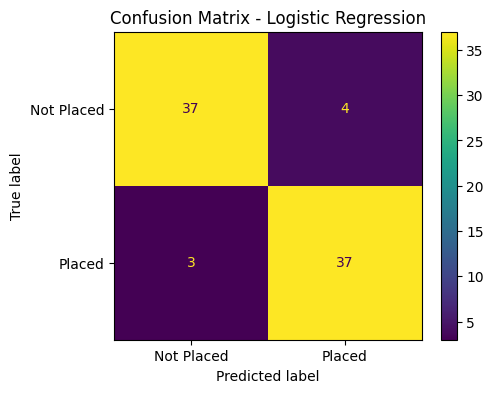

Random Forest
              precision    recall  f1-score   support

  Not Placed       0.92      0.88      0.90        41
      Placed       0.88      0.93      0.90        40

    accuracy                           0.90        81
   macro avg       0.90      0.90      0.90        81
weighted avg       0.90      0.90      0.90        81



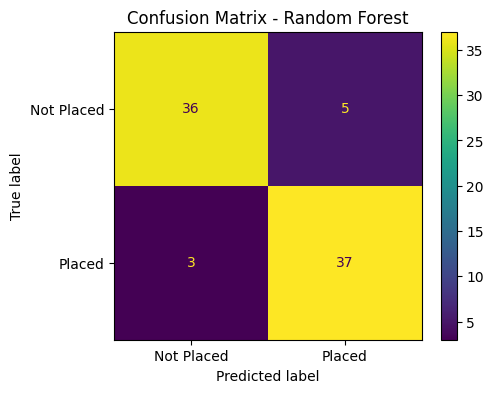

XGBoost
              precision    recall  f1-score   support

  Not Placed       0.90      0.88      0.89        41
      Placed       0.88      0.90      0.89        40

    accuracy                           0.89        81
   macro avg       0.89      0.89      0.89        81
weighted avg       0.89      0.89      0.89        81



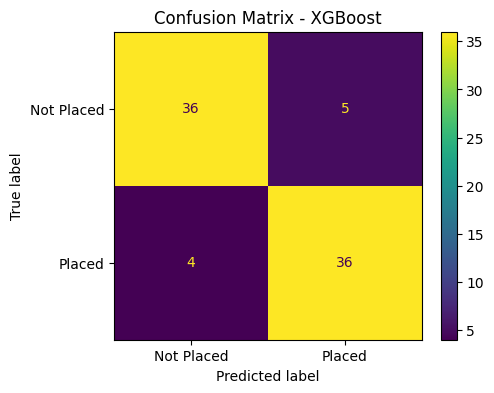

In [16]:
for name in results_df["Model"]:
    print("=" * 80)
    print(name)
    print("=" * 80)

    y_pred = fitted_models[name]["y_pred"]
    print(classification_report(y_test, y_pred, target_names=["Not Placed", "Placed"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Placed", "Placed"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# CHOOSING BEST MODEL

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]["pipeline"]

print("Best model selected:", best_model_name)
print("Reason: it has the highest F1 score on the test set, so it balances precision and recall well.")

Best model selected: Logistic Regression
Reason: it has the highest F1 score on the test set, so it balances precision and recall well.


In [18]:
with open("models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully ✅")

Model saved successfully ✅


## End of notebook

This version stops after model selection.  
Prediction helper, recommendation engine, and Streamlit app can be added in the next notebook or script.